In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import chi2
from sionna.rt import load_scene

import SceneConfigSionna
import nulling_cdf_utils as ncu

importlib.reload(SceneConfigSionna)
importlib.reload(ncu)

from SceneConfigSionna import SceneConfigSionna


In [2]:
scene = load_scene("/workspace/shizhen/NTN-Nulling/Denver_Scene/Boulder/Boulder.xml")
SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)


x range: [-3002.648, 2997.352]
y range: [-3010.112, 2999.888]


In [3]:
# Geometry and deployment
ntn_rx = 200
tn_rx = 300
bs_row = 2
bs_col = 2
nbs = bs_row * bs_col
nsect = 3

# Satellite sampling configuration for Monte Carlo
satellite_resample_per_macro = True
satellite_azimuth_range_deg = (0.0, 360.0)
satellite_elevation_range_deg = (45.0, 90.0)
azimuth = float(satellite_azimuth_range_deg[0])
elevation = float(satellite_elevation_range_deg[0])

# Carrier and array configuration
fc = 9.99e9
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows * tx_antenna_cols

# TX sector orientation
tx_sector_yaw_offset_deg = 0.0
tx_head_down_deg = 5.0
tx_sector_roll_deg = 0.0

tx_sector_yaw_offset_rad = np.deg2rad(tx_sector_yaw_offset_deg)
tx_sector_pitch_rad = -np.deg2rad(tx_head_down_deg)
tx_sector_roll_rad = np.deg2rad(tx_sector_roll_deg)

# Monte Carlo setting
num_macro_sims = 3
show_progress = True
plot_layout_on_first_sim = False

# Noise, thresholds, and MUSIC setup
EkT = -174
B = 100e6
Tx_power_dbm = 35
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)
Tx_power_handheld_dbm = 23
Tx_power_handheld = 10 ** ((Tx_power_handheld_dbm - 30) / 10)

NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B) + NF_bs - 30) / 10)

preamble_time = 20e-6
N0_sigma = N0_vsat / Tx_power / preamble_time
N0_sigma_handheld = 10 ** ((EkT + NF_bs - 30) / 10) / Tx_power_handheld / preamble_time

# lambda_ranges = [1e10, 1e11, 1e12, 1e13]
# lambda_ranges = [1e1, 1e2, 1e3]
lambda_ranges = None
lambda_ranges_music_est = [1e10, 1e10*3, 1e10*5]
lambda_ranges_music_real = lambda_ranges_music_est
max_detected_b_terms = "all"
snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10 ** (inr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
h_tn_th = np.sqrt(10 ** (snr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
threshold_peft_db = 10 * np.log10(np.abs(h_tn_th) ** 2)
p_fa = 1 / B
pfa_threshold = chi2.ppf(1 - p_fa, 2 * tx_antennas) / 2
h_ntn_pfa_th = np.sqrt(pfa_threshold * N0_sigma)
h_tn_pfa_th = np.sqrt(pfa_threshold * N0_sigma_handheld)
threshold_ntn_pfa_db = 10 * np.log10(np.abs(h_ntn_pfa_th) ** 2)
threshold_tn_pfa_db = 10 * np.log10(np.abs(h_tn_pfa_th) ** 2)

sionna_phi_is_global = True
theta_display_mode = "elevation"

# MUSIC detection tuning notes:
# - Lower threshold detects more users but may increase false alarms.
# - Higher threshold is stricter but may increase missed detections.
# - If music_num_sources is set to an integer, it overrides automatic K estimation.
# - source_estimation='mdl' is usually more conservative.
# - source_estimation='energy' is usually more aggressive.
# - music_energy_ratio is only used when source_estimation='energy'.
# - A larger music_energy_ratio usually yields a larger estimated K and looser detection.
music_num_sources = None
music_threshold = 5.0
music_covariance_mode = "sample"
music_num_snapshots = 200
music_noise_var = N0_bs / Tx_power
music_rng_seed = 7
music_source_estimation = "mdl"
music_energy_ratio = 0.95
music_reduce_ntn_ant = "max"
music_user_powers = None
music_use_sector_orientation = True
music_sector_pitch_rad = float(tx_sector_pitch_rad)
music_sector_roll_rad = float(tx_sector_roll_rad)
music_rotation_order = "zyx"
music_std_channel_mode = "conj"
music_std_manifold_label = "yz:+1"
music_std_flatten_order = "F"
music_std_scan_mode = "complex"
music_std_phi_offset_deg = 0.0
music_std_phi_mirror_about_sector = False
music_std_horizontal_sign = -1
music_sector_forward_only = True
music_sector_forward_cos_min = 0.0
music_phi_grid_deg = np.arange(0.0, 360.0, 1.0)
music_theta_grid_deg = np.arange(0.0, 181.0, 1.0)

print(
    f"TX sector orientation: yaw_offset={tx_sector_yaw_offset_deg:.1f} deg, "
    f"head_down={tx_head_down_deg:.1f} deg, roll={tx_sector_roll_deg:.1f} deg"
)
print(
    "Satellite sampling: "
    f"per_macro={satellite_resample_per_macro}, "
    f"azimuth_range={satellite_azimuth_range_deg}, "
    f"elevation_range={satellite_elevation_range_deg}"
)
print(f"h_tn_th = {h_tn_th:.4e}")
print(f"h_ntn_th = {h_ntn_th:.4e}")
print(f"TN Pfa threshold = {threshold_tn_pfa_db:.2f} dB")
print(f"NTN Pfa threshold = {threshold_ntn_pfa_db:.2f} dB")
print(f"Beamforming threshold = {threshold_peft_db:.2f} dB")
print(f"Detected NTN pair limit per TX = {max_detected_b_terms}")


TX sector orientation: yaw_offset=0.0 deg, head_down=5.0 deg, roll=0.0 deg
Satellite sampling: per_macro=True, azimuth_range=(0.0, 360.0), elevation_range=(45.0, 90.0)
h_tn_th = 1.7910e-06
h_ntn_th = 1.7910e-06
TN Pfa threshold = -127.24 dB
NTN Pfa threshold = -58.24 dB
Beamforming threshold = -114.94 dB
Detected NTN pair limit per TX = all


In [4]:
import importlib
import nulling_cdf_utils as ncu
importlib.reload(ncu)

result_dir = Path("result")
result_dir.mkdir(parents=True, exist_ok=True)

compute_positions_kwargs_mc = dict(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=1500,
    tn_building_ratio=0.6,
    tn_distance=400,
    ntn_building_ratio=0.8,
    plot_grid=plot_layout_on_first_sim,
    plot_bs=plot_layout_on_first_sim,
    plot_tn=plot_layout_on_first_sim,
    plot_ntn=plot_layout_on_first_sim,
)

compute_paths_kwargs_mc = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=0,
    bandwidth=B,
    tx_power_dbm=Tx_power_dbm,
    sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    sector_pitch_rad=tx_sector_pitch_rad,
    sector_roll_rad=tx_sector_roll_rad,
)

music_kwargs_mc = dict(
    tx_rows=int(tx_antenna_rows),
    tx_cols=int(tx_antenna_cols),
    nsect=int(nsect),
    pair_keys=None,
    detect_num_sources=music_num_sources,
    detect_threshold=music_threshold,
    detect_user_powers=music_user_powers,
    detect_noise_var=music_noise_var,
    detect_covariance_mode=music_covariance_mode,
    detect_num_snapshots=music_num_snapshots,
    detect_rng_seed=music_rng_seed,
    detect_source_estimation=music_source_estimation,
    detect_energy_ratio=music_energy_ratio,
    detect_reduce_rx_ant=music_reduce_ntn_ant,
    channel_mode=music_std_channel_mode,
    manifold_label=music_std_manifold_label,
    flatten_order=music_std_flatten_order,
    scan_mode=music_std_scan_mode,
    phi_offset_deg=music_std_phi_offset_deg,
    phi_mirror_about_sector=music_std_phi_mirror_about_sector,
    steering_horizontal_sign=music_std_horizontal_sign,
    use_sector_orientation=music_use_sector_orientation,
    sector_pitch_rad=music_sector_pitch_rad,
    sector_roll_rad=music_sector_roll_rad,
    rotation_order=music_rotation_order,
    sector_forward_only=music_sector_forward_only,
    sector_forward_cos_min=music_sector_forward_cos_min,
    phi_grid_deg=music_phi_grid_deg,
    theta_grid_deg=music_theta_grid_deg,
)

nulling_cdf_results = ncu.run_nulling_cdf_experiment(
    SceneConfig,
    num_macro_sims=num_macro_sims,
    compute_positions_kwargs=compute_positions_kwargs_mc,
    compute_paths_kwargs=compute_paths_kwargs_mc,
    lambda_ranges=lambda_ranges,
    lambda_ranges_music_est=lambda_ranges_music_est,
    lambda_ranges_music_real=lambda_ranges_music_real,
    h_tn_th=h_tn_th,
    tx_antennas=tx_antennas,
    tx_power=Tx_power,
    snr_noise_power=N0,
    inr_noise_power=N0_vsat,
    music_kwargs=music_kwargs_mc,
    sionna_phi_is_global=sionna_phi_is_global,
    theta_display_mode=theta_display_mode,
    plot_first_sim_only=plot_layout_on_first_sim,
    show_progress=show_progress,
    resample_satellite_per_macro=satellite_resample_per_macro,
    satellite_azimuth_range_deg=satellite_azimuth_range_deg,
    satellite_elevation_range_deg=satellite_elevation_range_deg,
    max_detected_b_terms=max_detected_b_terms,
)

metrics_path = ncu.save_experiment_metrics(
    nulling_cdf_results,
    result_dir=result_dir,
    output_name="nulling_cdf_metrics.npz",
)

macro_stats = nulling_cdf_results["macro_stats"]
macro_min_count = np.asarray([row["min_count"] for row in macro_stats], dtype=int)
macro_detected_ntn = np.asarray([row["detected_ntn_count"] for row in macro_stats], dtype=int)
macro_interfered_ntn = np.asarray([row["interfered_ntn_count"] for row in macro_stats], dtype=int)
macro_satellite_azimuth_deg = np.asarray([row["satellite_azimuth_deg"] for row in macro_stats], dtype=np.float64)
macro_satellite_elevation_deg = np.asarray([row["satellite_elevation_deg"] for row in macro_stats], dtype=np.float64)
macro_phi_mae_deg = np.asarray([row["angle_metrics"].get("phi_mae_deg", np.nan) for row in macro_stats], dtype=np.float64)
macro_elev_mae_deg = np.asarray([row["angle_metrics"].get("elev_mae_deg", np.nan) for row in macro_stats], dtype=np.float64)

print(f"Number of macro simulations: {num_macro_sims}")
print(f"Macro simulations with min_count > 0: {np.count_nonzero(macro_min_count > 0)}")
print(f"Average min_count: {macro_min_count.mean() if macro_min_count.size else 0:.2f}")
print(f"Average detected NTN count: {macro_detected_ntn.mean() if macro_detected_ntn.size else 0:.2f}")
print(f"Average interfered NTN count: {macro_interfered_ntn.mean() if macro_interfered_ntn.size else 0:.2f}")
print("Satellite angles by macro:")
for idx, (sat_az_deg, sat_el_deg) in enumerate(zip(macro_satellite_azimuth_deg, macro_satellite_elevation_deg)):
    print(f"  macro {idx}: az={sat_az_deg:.2f} deg, el={sat_el_deg:.2f} deg")
print(f"Average phi MAE: {np.nanmean(macro_phi_mae_deg) if macro_phi_mae_deg.size else np.nan:.3f} deg")
print(f"Average elevation MAE: {np.nanmean(macro_elev_mae_deg) if macro_elev_mae_deg.size else np.nan:.3f} deg")
print(f"Raw INR samples: {nulling_cdf_results['raw_inr_db'].size}")
print(f"Raw SNR samples: {nulling_cdf_results['raw_snr_db'].size}")
for lambda_ in (lambda_ranges or []):
    print(
        f"Detected h + nulling_bf, lambda={lambda_:.0e}: "
        f"INR={nulling_cdf_results['true_inr_db'][float(lambda_)].size}, "
        f"SNR={nulling_cdf_results['true_snr_db'][float(lambda_)].size}"
    )
for lambda_ in lambda_ranges_music_est:
    print(
        f"MUSIC est, lambda={lambda_:.0e}: "
        f"INR={nulling_cdf_results['est_inr_db'][float(lambda_)].size}, "
        f"SNR={nulling_cdf_results['est_snr_db'][float(lambda_)].size}"
    )
for lambda_ in lambda_ranges_music_real:
    print(
        f"Detected h -> true u,g, lambda={lambda_:.0e}: "
        f"INR={nulling_cdf_results['music_real_inr_db'][float(lambda_)].size}, "
        f"SNR={nulling_cdf_results['music_real_snr_db'][float(lambda_)].size}"
    )
print(f"Metrics saved to: {metrics_path}")


Monte Carlo:   0%|          | 0/3 [00:00<?, ?it/s]

[MUSIC sim] sim=0 sat_az_deg=349.02 sat_el_deg=70.62 det_ntn=170 interf_ntn=180 matched_pairs=505 u_pairs=505 tx_used=9 phi_mae_deg=3.715 elev_mae_deg=0.452 u_rho_mean=0.999120 u_err_mean=8.798278e-04 g_rel_err_mean=1.307834e-03
[MUSIC sim] sim=1 sat_az_deg=315.98 sat_el_deg=45.58 det_ntn=168 interf_ntn=184 matched_pairs=567 u_pairs=569 tx_used=12 phi_mae_deg=7.348 elev_mae_deg=0.689 u_rho_mean=0.999072 u_err_mean=9.284076e-04 g_rel_err_mean=1.440850e-03
[MUSIC sim] sim=2 sat_az_deg=10.95 sat_el_deg=76.15 det_ntn=144 interf_ntn=179 matched_pairs=339 u_pairs=339 tx_used=11 phi_mae_deg=2.229 elev_mae_deg=0.386 u_rho_mean=0.998964 u_err_mean=1.035854e-03 g_rel_err_mean=1.704100e-03
Number of macro simulations: 3
Macro simulations with min_count > 0: 3
Average min_count: 8.67
Average detected NTN count: 160.67
Average interfered NTN count: 181.00
Satellite angles by macro:
  macro 0: az=349.02 deg, el=70.62 deg
  macro 1: az=315.98 deg, el=45.58 deg
  macro 2: az=10.95 deg, el=76.15 deg
Av

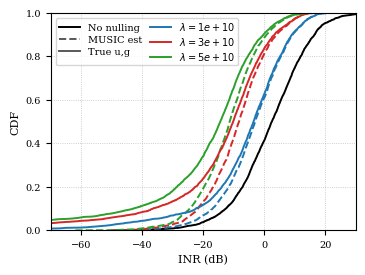

INR CDF PNG: result/nulling_inr_cdf.png
INR CDF PDF: result/nulling_inr_cdf.pdf


In [5]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "lines.linewidth": 1.4,
    }
)

fig, ax = plt.subplots(figsize=(3.5, 2.6))

raw_inr = np.asarray(nulling_cdf_results["raw_inr_db"], dtype=np.float64)
raw_inr = raw_inr[np.isfinite(raw_inr)]
if raw_inr.size > 0:
    raw_inr_sorted = np.sort(raw_inr)
    raw_inr_cdf = np.arange(1, raw_inr_sorted.size + 1, dtype=np.float64) / float(raw_inr_sorted.size)
    ax.plot(raw_inr_sorted, raw_inr_cdf, color="black", linestyle="-", label="No nulling")

color_cycle = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#8c564b", "#17becf"]

# for idx, lambda_ in enumerate(sorted(nulling_cdf_results["true_inr_db"].keys())):
#     values = np.asarray(nulling_cdf_results["true_inr_db"][lambda_], dtype=np.float64)
#     values = values[np.isfinite(values)]
#     if values.size == 0:
#         continue

#     values_sorted = np.sort(values)
#     values_cdf = np.arange(1, values_sorted.size + 1, dtype=np.float64) / float(values_sorted.size)
#     ax.plot(
#         values_sorted,
#         values_cdf,
#         color=color_cycle[idx % len(color_cycle)],
#         linestyle="-",
#         label=f"Detected h + nulling_bf, $\\lambda={float(lambda_):.0e}$",
#     )

lambda_color_map_inr = {
    float(lambda_): color_cycle[idx % len(color_cycle)]
    for idx, lambda_ in enumerate(
        sorted(
            set(float(v) for v in nulling_cdf_results["est_inr_db"].keys())
            | set(float(v) for v in nulling_cdf_results["music_real_inr_db"].keys())
        )
    )
}
lambda_keys_inr = set()

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["est_inr_db"].keys())):
    values = np.asarray(nulling_cdf_results["est_inr_db"][lambda_], dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        continue

    lambda_keys_inr.add(float(lambda_))
    values_sorted = np.sort(values)
    values_cdf = np.arange(1, values_sorted.size + 1, dtype=np.float64) / float(values_sorted.size)
    ax.plot(
        values_sorted,
        values_cdf,
        color=lambda_color_map_inr[float(lambda_)],
        linestyle="--",
    )

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["music_real_inr_db"].keys())):
    values = np.asarray(nulling_cdf_results["music_real_inr_db"][lambda_], dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        continue

    lambda_keys_inr.add(float(lambda_))
    values_sorted = np.sort(values)
    values_cdf = np.arange(1, values_sorted.size + 1, dtype=np.float64) / float(values_sorted.size)
    ax.plot(
        values_sorted,
        values_cdf,
        color=lambda_color_map_inr[float(lambda_)],
        linestyle="-",
    )

style_handles = []
if len(nulling_cdf_results["est_inr_db"]) > 0:
    style_handles.append(
        Line2D([0], [0], color="0.35", linestyle="--", linewidth=1.4, label="MUSIC est")
    )
if len(nulling_cdf_results["music_real_inr_db"]) > 0:
    style_handles.append(
        Line2D([0], [0], color="0.35", linestyle="-", linewidth=1.4, label="True u,g")
    )
lambda_handles = [
    Line2D(
        [0],
        [0],
        color=lambda_color_map_inr[lambda_],
        linestyle="-",
        linewidth=1.4,
        label=f"$\\lambda={lambda_:.0e}$",
    )
    for idx, lambda_ in enumerate(sorted(lambda_keys_inr))
]
legend_handles, legend_labels = ax.get_legend_handles_labels()
legend_handles.extend(style_handles)
legend_labels.extend([handle.get_label() for handle in style_handles])
legend_handles.extend(lambda_handles)
legend_labels.extend([handle.get_label() for handle in lambda_handles])

ax.set_xlabel("INR (dB)")
ax.set_ylabel("CDF")
# ax.set_title("CDF of INR on MUSIC-detected NTN Pairs")
ax.set_ylim(0.0, 1.0)
ax.set_xlim(-70, 30)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper left",
    ncol=2,
    frameon=True,
    handlelength=2.2,
    borderpad=0.3,
    labelspacing=0.3,
    columnspacing=0.8,
)
fig.tight_layout(pad=0.2)

inr_png_path = result_dir / "nulling_inr_cdf.png"
inr_pdf_path = result_dir / "nulling_inr_cdf.pdf"
fig.savefig(inr_png_path, dpi=400, bbox_inches="tight")
fig.savefig(inr_pdf_path, bbox_inches="tight")
plt.show()

print(f"INR CDF PNG: {inr_png_path}")
print(f"INR CDF PDF: {inr_pdf_path}")


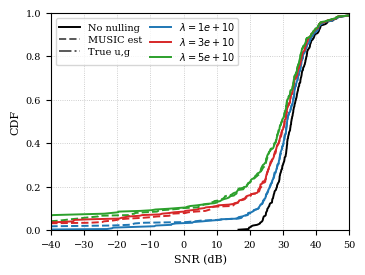

SNR CDF PNG: result/nulling_snr_cdf.png
SNR CDF PDF: result/nulling_snr_cdf.pdf


In [6]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "lines.linewidth": 1.4,
    }
)

fig, ax = plt.subplots(figsize=(3.5, 2.6))

raw_snr = np.asarray(nulling_cdf_results["raw_snr_db"], dtype=np.float64)
raw_snr = raw_snr[np.isfinite(raw_snr)]
if raw_snr.size > 0:
    raw_snr_sorted = np.sort(raw_snr)
    raw_snr_cdf = np.arange(1, raw_snr_sorted.size + 1, dtype=np.float64) / float(raw_snr_sorted.size)
    ax.plot(raw_snr_sorted, raw_snr_cdf, color="black", linestyle="-", label="No nulling")

color_cycle = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#8c564b", "#17becf"]

# for idx, lambda_ in enumerate(sorted(nulling_cdf_results["true_snr_db"].keys())):
#     values = np.asarray(nulling_cdf_results["true_snr_db"][lambda_], dtype=np.float64)
#     values = values[np.isfinite(values)]
#     if values.size == 0:
#         continue

#     values_sorted = np.sort(values)
#     values_cdf = np.arange(1, values_sorted.size + 1, dtype=np.float64) / float(values_sorted.size)
#     ax.plot(
#         values_sorted,
#         values_cdf,
#         color=color_cycle[idx % len(color_cycle)],
#         linestyle="-",
#         label=f"Detected h + nulling_bf, $\\lambda={float(lambda_):.0e}$",
#     )

lambda_color_map_snr = {
    float(lambda_): color_cycle[idx % len(color_cycle)]
    for idx, lambda_ in enumerate(
        sorted(
            set(float(v) for v in nulling_cdf_results["est_snr_db"].keys())
            | set(float(v) for v in nulling_cdf_results["music_real_snr_db"].keys())
        )
    )
}
lambda_keys_snr = set()

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["est_snr_db"].keys())):
    values = np.asarray(nulling_cdf_results["est_snr_db"][lambda_], dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        continue

    lambda_keys_snr.add(float(lambda_))
    values_sorted = np.sort(values)
    values_cdf = np.arange(1, values_sorted.size + 1, dtype=np.float64) / float(values_sorted.size)
    ax.plot(
        values_sorted,
        values_cdf,
        color=lambda_color_map_snr[float(lambda_)],
        linestyle="--",
    )

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["music_real_snr_db"].keys())):
    values = np.asarray(nulling_cdf_results["music_real_snr_db"][lambda_], dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        continue

    lambda_keys_snr.add(float(lambda_))
    values_sorted = np.sort(values)
    values_cdf = np.arange(1, values_sorted.size + 1, dtype=np.float64) / float(values_sorted.size)
    ax.plot(
        values_sorted,
        values_cdf,
        color=lambda_color_map_snr[float(lambda_)],
        linestyle="-",
    )

style_handles = []
if len(nulling_cdf_results["est_snr_db"]) > 0:
    style_handles.append(
        Line2D([0], [0], color="0.35", linestyle="--", linewidth=1.4, label="MUSIC est")
    )
if len(nulling_cdf_results["music_real_snr_db"]) > 0:
    style_handles.append(
        Line2D([0], [0], color="0.35", linestyle="-.", linewidth=1.4, label="True u,g")
    )
lambda_handles = [
    Line2D(
        [0],
        [0],
        color=lambda_color_map_snr[lambda_],
        linestyle="-",
        linewidth=1.4,
        label=f"$\\lambda={lambda_:.0e}$",
    )
    for idx, lambda_ in enumerate(sorted(lambda_keys_snr))
]
legend_handles, legend_labels = ax.get_legend_handles_labels()
legend_handles.extend(style_handles)
legend_labels.extend([handle.get_label() for handle in style_handles])
legend_handles.extend(lambda_handles)
legend_labels.extend([handle.get_label() for handle in lambda_handles])
ax.set_xlim(-40, 50)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("CDF")
# ax.set_title("CDF of SNR on Paired BS-TN Links")
ax.set_ylim(0.0, 1.0)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper left",
    ncol=2,
    frameon=True,
    handlelength=2.2,
    borderpad=0.3,
    labelspacing=0.3,
    columnspacing=0.8,
)
fig.tight_layout(pad=0.2)

snr_png_path = result_dir / "nulling_snr_cdf.png"
snr_pdf_path = result_dir / "nulling_snr_cdf.pdf"
fig.savefig(snr_png_path, dpi=400, bbox_inches="tight")
fig.savefig(snr_pdf_path, bbox_inches="tight")
plt.show()

print(f"SNR CDF PNG: {snr_png_path}")
print(f"SNR CDF PDF: {snr_pdf_path}")
